# FastOTF2 Converter Benchmark

One-click comparison of the **Chapel** `fastotf2` converter against **Python** and **C**
converters, measuring the wall-clock time to convert OTF2 traces to tabular output.

| Tool | CSV | Parquet |
|------|-----|---------|
| Chapel (`fastotf2` container) | ✓ | ✓ |
| Python (`otf2` + pyarrow) | ✓ | ✓ |
| C (OTF2 C library) | ✓ | — (Arrow toolchain out of scope) |

All three converters ship inside **one Apptainer container**, so they use an identical
OTF2 version and the workflow is portable: the only host requirements are Apptainer + SLURM
and readable trace paths.

**All configuration lives in the config cell below** — there is no external config file.

Traces are labelled by their **measured on-disk size in GiB** (e.g. `11.6GiB`), not by node
count, so every run and every results row is keyed by data size.

## How runs are organised

Each execution of the **config cell (§0)** mints a fresh timestamped `RUN_TAG` and its own
folder under `out/`, so runs never clobber each other:

```
out/run_YYYYMMDD_HHMMSS/
  config.json      # exact parameters used (provenance)
  run.sbatch       # the generated SLURM script that was submitted
  results.csv      # timings for this run
  slurm_logs/      # SLURM stdout/stderr for this run
  run_logs/        # per-conversion converter logs
  scratch/         # conversion output (deleted between runs; large)
  plots/           # rendered table + chart
```

- **New run:** Run All (or run §0→§3). A new `RUN_DIR` is created and submitted.
- **Re-analyse a previous run** (no new data): restart the kernel, run the §0 imports, then
  in §4 set `ANALYZE_RUN = "run_YYYYMMDD_HHMMSS"` (a tag or a path) and run the analysis
  cells. Nothing is resubmitted.
- **Resubmit while another run is going:** the running SLURM job is independent, so you can
  restart this kernel and launch a fresh run at any time — they write to different folders.

> The default trace set here is **~0.7 GiB + ~11.6 GiB** (the 2- and 16-node traces). The
> **~32.7 GiB** (32-node) trace is deliberately excluded so this run does not interfere with
> a separately-running 32-node job; combine results later if needed.


# 0. Configuration & run folder

Everything you might change lives in this one cell. Running it creates a new timestamped
run folder under `out/`. Set `DRY_RUN = True` to preview submission without launching.

In [1]:
import os, json, shlex, subprocess, time
from pathlib import Path
from datetime import datetime

REPO_DIR = Path.cwd()
assert (REPO_DIR / "benchmark" / "run_one.sh").exists(), \
    f"Run this notebook from the repo root; benchmark/run_one.sh not found in {REPO_DIR}"

# ======================== USER CONFIGURATION ========================
# --- Container image (build target + what the benchmark runs against) ---
# Use the freshly-rebuilt image (adds the Python progress heartbeat + fast-tools-first
# combo order). It is a SEPARATE file from container/fastotf2-bench.sif, which a
# previously-launched job may still be using -- so pointing here does not disturb it.
IMAGE       = REPO_DIR / "container" / "fastotf2-bench-next.sif"
BASE_IMAGE  = "ghcr.io/hpc-ai-adv-dev/fastotf2/fastotf2-converter:latest"  # portable, single-locale

# --- Traces: just list the directories (each holds the OTF2 anchor traces.otf2).
#     Each trace is labelled automatically by its real on-disk size in GiB
#     (measured with `du -sb`), so runs and results are keyed by DATA SIZE, not
#     node count. Default set: the ~0.7 GiB and ~11.6 GiB traces. The ~32.7 GiB
#     (32-node) trace is intentionally left OUT so this run neither duplicates nor
#     interferes with the separately-running 32-node job. ---
TRACE_PATHS = [
    "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-2-node-single-HPL-run",
    "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-16-node-single-HPL-run",
]
TRACE_ANCHOR = "traces.otf2"

# --- Which (tool, format) combos to run. Each becomes its OWN SLURM job, so order
#     does not matter for timing -- they run in parallel on separate nodes. ---
COMBOS = [
    ("chapel", "CSV"), ("chapel", "PARQUET"),
    ("c",      "CSV"),
    ("python", "CSV"), ("python", "PARQUET"),
]

REPEATS      = 1     # timed repeats per combo (averaged in analysis)
CHPL_THREADS = 0     # Chapel threads/locale; 0 = all node cores

# --- SLURM ---
# Account/partition are site-specific and usually unnecessary; leave them blank to
# use your cluster's defaults. Set them only if your site requires an explicit value.
SLURM_ACCOUNT   = ""          # e.g. "myproject"  (blank -> no --account flag)
SLURM_PARTITION = ""          # e.g. "batch"      (blank -> no --partition flag)
SLURM_TIME      = "12:00:00"
SLURM_EXCLUSIVE = True

# --- Preview without submitting? ---
DRY_RUN = False
# ====================================================================

# --- Label each trace by its measured on-disk size in GiB (du -sb, 1024**3) ---
_GIB = 1024 ** 3
def measure_gib(path):
    out = subprocess.run(["du", "-sb", path], capture_output=True, text=True, check=True)
    return int(out.stdout.split()[0]) / _GIB

TRACES = {}   # size label (e.g. "11.6GiB") -> trace directory
for _p in TRACE_PATHS:
    _gib = measure_gib(_p)
    TRACES[f"{_gib:.1f}GiB"] = _p

# --- Fresh, timestamped run folder (never clobbers a previous run) ---
RUN_TAG = f"run_{datetime.now():%Y%m%d_%H%M%S}"
OUT_ROOT = REPO_DIR / "out"
RUN_DIR  = OUT_ROOT / RUN_TAG
for sub in ("slurm_logs", "run_logs", "timings", "scratch", "plots"):
    (RUN_DIR / sub).mkdir(parents=True, exist_ok=True)
TIMINGS_DIR = RUN_DIR / "timings"      # one small CSV per conversion job
RESULTS_CSV = RUN_DIR / "results.csv"  # merged from timings/ after jobs finish

CONFIG = {
    "run_tag": RUN_TAG, "image": str(IMAGE), "base_image": BASE_IMAGE,
    "traces": TRACES, "trace_anchor": TRACE_ANCHOR,
    "combos": [f"{t}|{f}" for t, f in COMBOS], "repeats": REPEATS,
    "chpl_threads": CHPL_THREADS,
    "slurm": {"account": SLURM_ACCOUNT, "partition": SLURM_PARTITION,
              "time": SLURM_TIME, "exclusive": SLURM_EXCLUSIVE},
}
(RUN_DIR / "config.json").write_text(json.dumps(CONFIG, indent=2))

print(f"RUN_TAG : {RUN_TAG}")
print(f"RUN_DIR : {RUN_DIR}")
print(f"IMAGE   : {IMAGE}")
print(f"traces  : {', '.join(f'{lbl} ({os.path.basename(p)})' for lbl, p in TRACES.items())}")
print(f"combos  : {', '.join(f'{t}({f})' for t, f in COMBOS)}")
print(f"jobs    : {len(TRACES) * len(COMBOS) * REPEATS} (one SLURM job each, run in parallel)")
print(f"DRY_RUN : {DRY_RUN}")


RUN_TAG : run_20260714_150908
RUN_DIR : /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2-bench/out/run_20260714_150908
IMAGE   : /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2-bench/container/fastotf2-bench-next.sif
traces  : 0.7GiB (frontier-2-node-single-HPL-run), 11.6GiB (frontier-16-node-single-HPL-run)
combos  : chapel(CSV), chapel(PARQUET), c(CSV), python(CSV), python(PARQUET)
jobs    : 10 (one SLURM job each, run in parallel)
DRY_RUN : False


# 1. Container image

Builds the bench image if `IMAGE` does not exist yet (one-time, ~minutes). Uses the
cached base image; installs the Python stack and compiles the C converter inside.

In [2]:
if IMAGE.exists():
    print("Bench image present:", IMAGE)
else:
    print("Bench image missing — building it now (one-time)...")
    env = {**os.environ, "BENCH_SIF": str(IMAGE),
           "BENCH_IMAGE_TAG": "localhost/fastotf2-bench:latest",
           "BENCH_BASE_IMAGE": BASE_IMAGE}
    subprocess.run(["bash", str(REPO_DIR / "container" / "build-bench-image.sh")],
                   cwd=REPO_DIR, env=env, check=True)
    print("Build complete:", IMAGE)

Bench image present: /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2-bench/container/fastotf2-bench-next.sif


# 2. Submit the benchmark to SLURM (one job per conversion)

Each `(trace, tool, format, repeat)` is submitted as its **own independent, exclusive**
SLURM job, so they run **in parallel** on separate nodes — e.g. Python CSV and Python
Parquet proceed simultaneously rather than back-to-back. Every job writes its own one-row
timing CSV under `timings/` (no shared-file contention), and its own generated `run_logs/
<tag>.sbatch` is saved for provenance. With `DRY_RUN = True`, scripts are written but
nothing is submitted.


In [3]:
import itertools

def sbatch_for(trace_label, trace_dir, tool, fmt, rep):
    """Text of a per-conversion sbatch script (config baked in for provenance)."""
    tag = f"{trace_label}_{tool}_{fmt}_r{rep}"
    result_file = TIMINGS_DIR / f"{tag}.csv"
    out_dir     = RUN_DIR / "scratch" / tag
    lines = ["#!/usr/bin/env bash",
             f"#SBATCH --job-name=f2b-{RUN_TAG}-{tag}",
             "#SBATCH --nodes=1",
             f"#SBATCH --time={SLURM_TIME}",
             f"#SBATCH --output={RUN_DIR}/slurm_logs/{tag}-%j.out",
             f"#SBATCH --error={RUN_DIR}/slurm_logs/{tag}-%j.err"]
    if SLURM_EXCLUSIVE:
        lines.append("#SBATCH --exclusive")
    if SLURM_ACCOUNT:
        lines.append(f"#SBATCH --account={SLURM_ACCOUNT}")
    if SLURM_PARTITION:
        lines.append(f"#SBATCH --partition={SLURM_PARTITION}")
    lines += [
        "",
        f"export BENCH_SIF={shlex.quote(str(IMAGE))}",
        f"export BENCH_RUN_TAG={shlex.quote(RUN_TAG)}",
        f"export BENCH_TRACE_DIR={shlex.quote(trace_dir)}",
        f"export BENCH_TRACE_LABEL={shlex.quote(trace_label)}",
        f"export BENCH_TOOL={shlex.quote(tool)}",
        f"export BENCH_FORMAT={shlex.quote(fmt)}",
        f"export BENCH_REPEAT={rep}",
        f"export BENCH_OUTPUT_DIR={shlex.quote(str(out_dir))}",
        f"export BENCH_RESULT_FILE={shlex.quote(str(result_file))}",
        f"export BENCH_TRACE_ANCHOR={shlex.quote(TRACE_ANCHOR)}",
        f"export BENCH_CHPL_THREADS={CHPL_THREADS}",
        "",
        f"bash {shlex.quote(str(REPO_DIR / 'benchmark' / 'run_one.sh'))}",
        "",
    ]
    return tag, "\n".join(lines)

jobs, manifest = [], []
for (label, path), (tool, fmt), rep in itertools.product(
        TRACES.items(), COMBOS, range(1, REPEATS + 1)):
    tag, script = sbatch_for(label, path, tool, fmt, rep)
    sb_path = RUN_DIR / "run_logs" / f"{tag}.sbatch"
    sb_path.write_text(script)
    if DRY_RUN:
        jobs.append({"tag": tag, "job_id": None})
        print(f"[dry] would submit {tag}")
        continue
    res = subprocess.run(["sbatch", "--parsable", str(sb_path)],
                         cwd=REPO_DIR, capture_output=True, text=True)
    if res.returncode != 0:
        raise RuntimeError(f"sbatch failed for {tag}:\n{res.stderr}")
    jid = res.stdout.strip().split(";")[0]
    jobs.append({"tag": tag, "job_id": jid})
    manifest.append(f"{jid},{tag}")
    print(f"submitted {jid}  {tag}")

JOB_IDS = [j["job_id"] for j in jobs if j["job_id"]]
(RUN_DIR / "manifest.csv").write_text("job_id,tag\n" + "".join(m + "\n" for m in manifest))
if DRY_RUN:
    print("\nDRY_RUN=True — nothing submitted. Per-job scripts written under run_logs/.")
else:
    print(f"\nSubmitted {len(JOB_IDS)} parallel jobs for run {RUN_TAG}.")
    print(f"Manifest: {RUN_DIR / 'manifest.csv'}")


submitted 1544560  0.7GiB_chapel_CSV_r1
submitted 1544561  0.7GiB_chapel_PARQUET_r1
submitted 1544562  0.7GiB_c_CSV_r1
submitted 1544563  0.7GiB_python_CSV_r1
submitted 1544564  0.7GiB_python_PARQUET_r1
submitted 1544565  11.6GiB_chapel_CSV_r1
submitted 1544566  11.6GiB_chapel_PARQUET_r1
submitted 1544567  11.6GiB_c_CSV_r1
submitted 1544568  11.6GiB_python_CSV_r1
submitted 1544569  11.6GiB_python_PARQUET_r1

Submitted 10 parallel jobs for run run_20260714_150908.
Manifest: /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2-bench/out/run_20260714_150908/manifest.csv


# 3. Monitor / wait for all jobs

Polls `squeue` until every submitted job has left the queue, printing a running
done/total tally by state. Safe to interrupt and re-run — it just watches. Each job writes
its own `timings/<tag>.csv` the moment it finishes, so §4 works on partial data at any time.
Per-job progress (including the Python heartbeat) is in `slurm_logs/<tag>-<jobid>.out`.


In [5]:
import collections
import pandas as pd

if DRY_RUN or not JOB_IDS:
    print("No jobs submitted (DRY_RUN). Skipping wait.")
else:
    print(f"Waiting for {len(JOB_IDS)} jobs (Ctrl-C to stop watching; results are per-job)...")
    while True:
        q = subprocess.run(["squeue", "-h", "-o", "%i %T", "-j", ",".join(JOB_IDS)],
                           capture_output=True, text=True)
        rows = [ln.split() for ln in q.stdout.splitlines() if ln.strip()]
        if not rows:
            break
        counts = collections.Counter(r[1] for r in rows)
        done = len(JOB_IDS) - len(rows)
        print(f"  [{time.strftime('%H:%M:%S')}] {done}/{len(JOB_IDS)} finished; "
              + ", ".join(f"{k}:{v}" for k, v in sorted(counts.items())), flush=True)
        time.sleep(15)
    print("All jobs have left the queue.\n")

# Merge whatever per-job timing files exist into one results.csv (partial data is fine).
_parts = [pd.read_csv(f) for f in sorted(TIMINGS_DIR.glob("*.csv"))]
if _parts:
    merged = pd.concat(_parts, ignore_index=True)
    merged.to_csv(RESULTS_CSV, index=False)
    print(f"Merged {len(_parts)} timing file(s) -> {RESULTS_CSV}\n")
    print(merged.to_string(index=False))
else:
    print(f"No timing files yet under {TIMINGS_DIR}")


Waiting for 10 jobs (Ctrl-C to stop watching; results are per-job)...
  [15:16:20] 7/10 finished; RUNNING:3


  [15:16:35] 7/10 finished; RUNNING:3
  [15:16:50] 7/10 finished; RUNNING:3
  [15:17:05] 7/10 finished; RUNNING:3
  [15:17:20] 7/10 finished; RUNNING:3
  [15:17:35] 7/10 finished; RUNNING:3
  [15:17:50] 7/10 finished; RUNNING:3
  [15:18:05] 7/10 finished; RUNNING:3
  [15:18:20] 7/10 finished; RUNNING:3
  [15:18:35] 7/10 finished; RUNNING:3
  [15:18:50] 7/10 finished; RUNNING:3
  [15:19:05] 7/10 finished; RUNNING:3
  [15:19:20] 7/10 finished; RUNNING:3


KeyboardInterrupt: 

# 4. Results analysis

**Self-contained** — needs only a run's `results.csv`, so you can restart the kernel and run
just this section.

- `ANALYZE_RUN = None` → the run created above this session; if the kernel is fresh, the
  most recent run under `out/`.
- `ANALYZE_RUN = "run_YYYYMMDD_HHMMSS"` (a tag) or a full path → analyse that **previous**
  run without collecting new data.

In [13]:
import re
from pathlib import Path
import pandas as pd
from plotnine import *  # noqa: F401,F403

# === Which run to analyse? ===
# None -> the run created above this session (or the latest under out/ on a fresh kernel).
# tag  -> a previous run's tag, e.g. "run_20260714_101500", or a full path.
ANALYZE_RUN = None

_OUT_ROOT = (REPO_DIR / "out") if "REPO_DIR" in globals() else (Path.cwd() / "out")

def resolve_run_dir(analyze_run):
    if analyze_run:
        p = Path(analyze_run)
        if not p.exists():
            p = _OUT_ROOT / analyze_run
        return p.parent if p.is_file() else p
    if "RUN_DIR" in globals():
        return Path(globals()["RUN_DIR"])
    runs = sorted(_OUT_ROOT.glob("run_*/timings"))
    if not runs:
        raise FileNotFoundError(f"No runs with timings/ under {_OUT_ROOT}")
    return runs[-1].parent

ANALYSIS_DIR = resolve_run_dir(ANALYZE_RUN)
PLOTS_DIR = ANALYSIS_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

tfiles = sorted((ANALYSIS_DIR / "timings").glob("*.csv"))
if not tfiles:
    raise FileNotFoundError(f"No per-job timing CSVs under {ANALYSIS_DIR / 'timings'}")
df = pd.concat([pd.read_csv(f) for f in tfiles], ignore_index=True)
print(f"Analysing run: {ANALYSIS_DIR.name}  ({len(df)} rows from {len(tfiles)} jobs)")
if (df["status"] != 0).any():
    print("WARNING: some conversions failed (status != 0):")
    print(df[df["status"] != 0][["trace", "tool", "format", "status"]].to_string(index=False))

ok = df[df["status"] == 0].copy()
agg = (ok.groupby(["trace", "tool", "format"], as_index=False)
         .agg(seconds=("seconds", "mean"), output_bytes=("output_bytes", "mean")))
agg["gib"] = agg["trace"].str.extract(r"([\d.]+)").astype(float)
agg["combo"] = agg["tool"].str.capitalize() + " (" + agg["format"] + ")"

# Ordered categoricals: traces ascending by real size; combos in a fixed reading order.
_trace_order = [t for _, t in sorted(set(zip(agg["gib"], agg["trace"])))]
agg["trace"] = pd.Categorical(agg["trace"], categories=_trace_order, ordered=True)
_combo_order = [c for c in ["Chapel (CSV)", "Chapel (PARQUET)", "C (CSV)",
                            "Python (CSV)", "Python (PARQUET)"] if c in set(agg["combo"])]
agg["combo"] = pd.Categorical(agg["combo"], categories=_combo_order, ordered=True)

# Save figures next to the run (kept alongside its data for provenance).
def _maybe_save(p, name, save=True):
    if save:
        p.save(PLOTS_DIR / f"{name}.png", dpi=150, verbose=False)

# Wide table for a quick numeric read-out (rows sorted by trace size).
table = (agg.pivot(index="trace", columns="combo", values="seconds").reindex(columns=_combo_order))
table.columns.name = None
table.index.name = "trace (size)"
print("\nConversion time (seconds), mean over repeats:")
table.round(2)


Analysing run: run_20260714_150908  (10 rows from 10 jobs)

Conversion time (seconds), mean over repeats:


,Chapel (CSV),Chapel (PARQUET),C (CSV),Python (CSV),Python (PARQUET)
trace (size),,,,,
0.7GiB,13.67,9.51,30.44,271.5,282.81
11.6GiB,29.55,25.12,581.52,4562.6,4771.69


In [14]:
# Speedup over the Python baseline, per format (tidy long form for plotnine).
_recs = []
_piv = agg.pivot_table(index=["trace", "gib"], columns=["format", "tool"],
                       values="seconds", observed=True)
for (trace, gib), row in _piv.iterrows():
    for fmt in row.index.get_level_values(0).unique():
        block = row[fmt]
        if "python" not in block or pd.isna(block.get("python")):
            continue
        for tool in block.index:
            if tool == "python" or pd.isna(block[tool]):
                continue
            _recs.append({"trace": trace, "gib": gib,
                          "comparison": f"{tool.capitalize()} ({fmt})",
                          "speedup": block["python"] / block[tool]})

speedup_long = pd.DataFrame(_recs)
if not speedup_long.empty:
    speedup_long["trace"] = pd.Categorical(speedup_long["trace"],
                                           categories=_trace_order, ordered=True)
    speedup_long = speedup_long.sort_values(["gib", "comparison"])
    print("Speedup over Python (x faster):")
    display(speedup_long.pivot(index="trace", columns="comparison", values="speedup").round(1))
else:
    print("No Python baseline available yet — speedup will appear once Python rows land.")


Speedup over Python (x faster):


comparison,C (CSV),Chapel (CSV),Chapel (PARQUET)
trace,,,
0.7GiB,8.9,19.9,29.8
11.6GiB,7.8,154.4,189.9


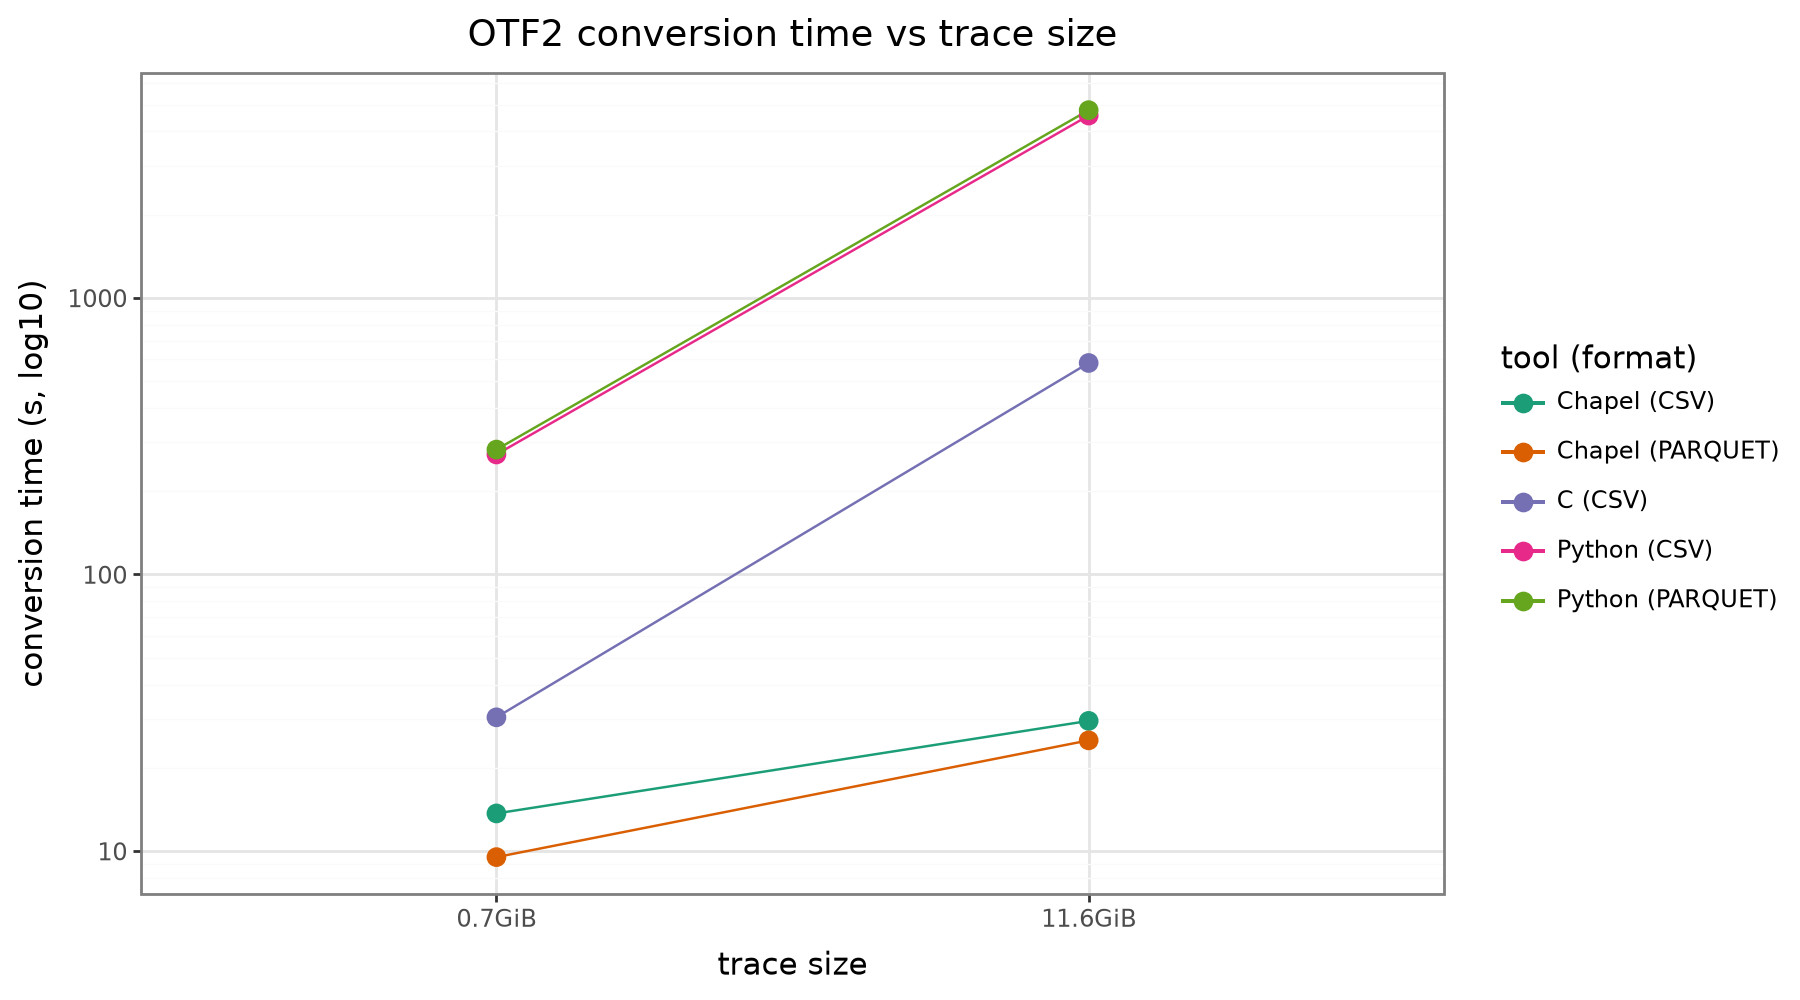

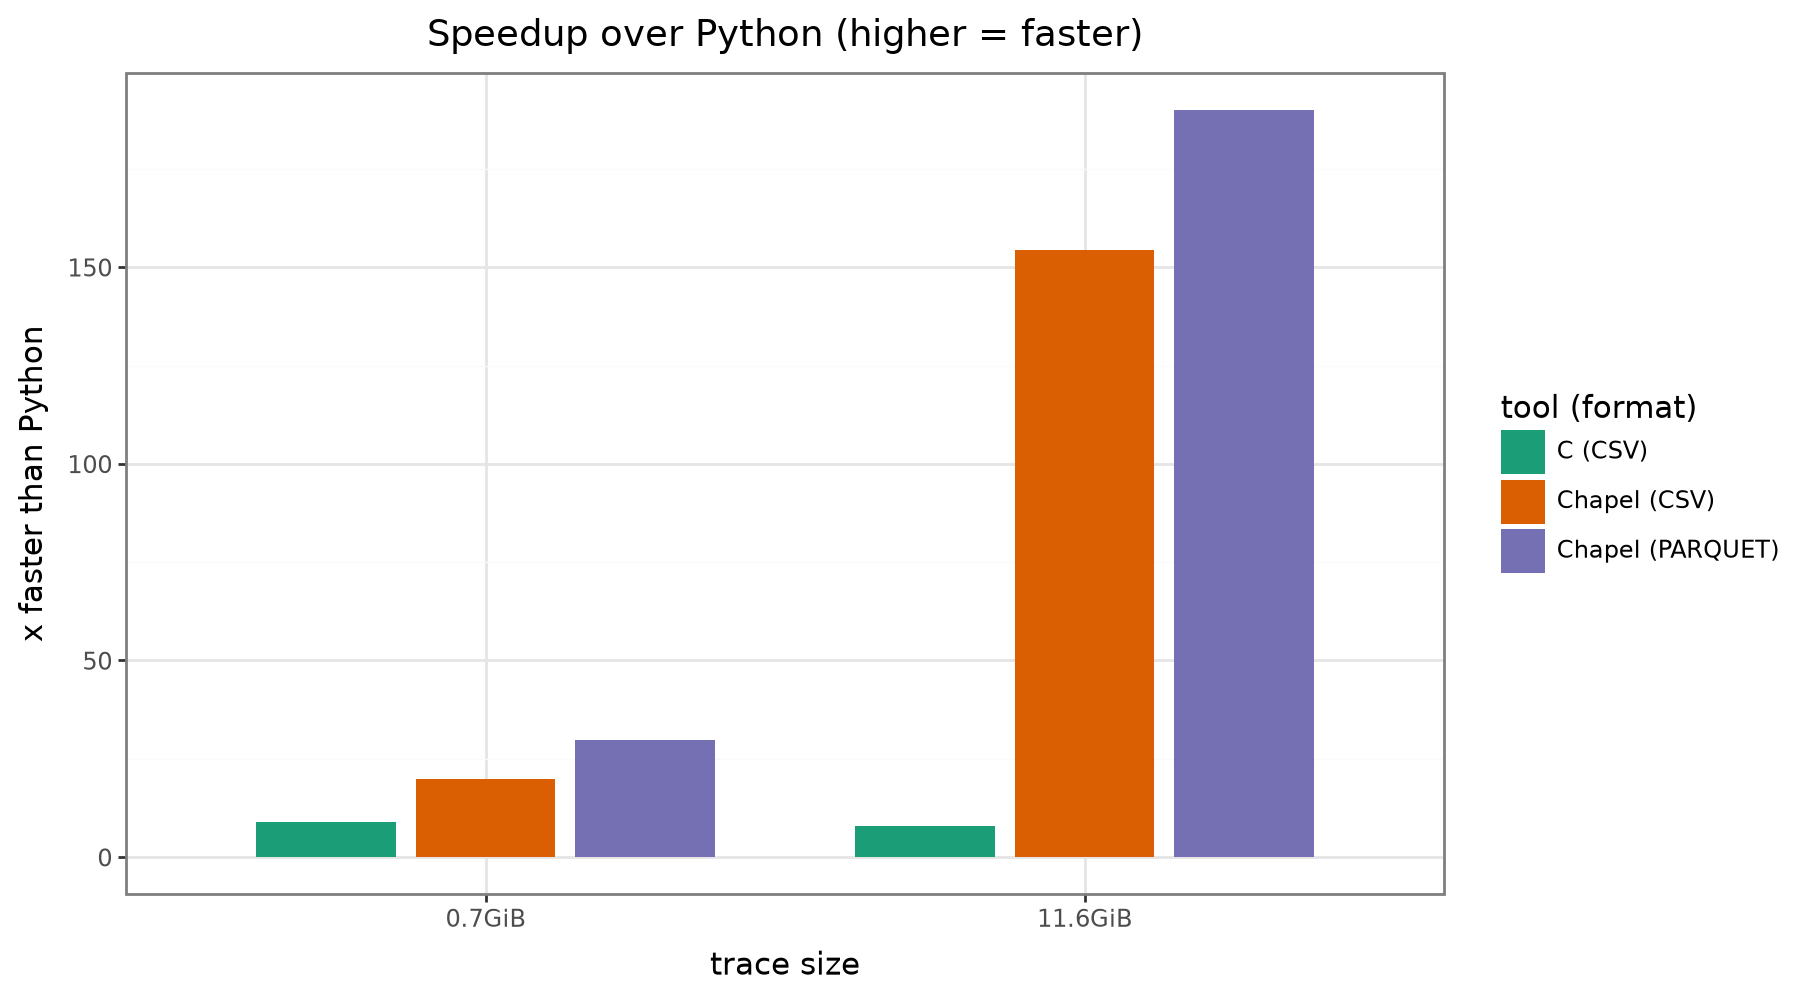

In [15]:
# --- Graphs (plotnine), following the scaling-notebook conventions ---
# G1: conversion time vs trace size. Times span orders of magnitude (Chapel seconds vs
# Python thousands of seconds), so a log10 y-axis is used with points + connecting lines
# (a trend across data size) rather than bars, which keeps the log axis honest.
p_time = (
    ggplot(agg, aes("trace", "seconds", color="combo", group="combo"))
    + geom_line()
    + geom_point(size=3)
    + scale_y_log10()
    + scale_color_brewer(type="qual", palette="Dark2")
    + labs(title="OTF2 conversion time vs trace size",
           x="trace size", y="conversion time (s, log10)", color="tool (format)")
    + theme_bw()
    + theme(figure_size=(9, 5))
)
display(p_time)
_maybe_save(p_time, "g1_time")

# G2: speedup over Python -- a ratio, so bars from y=0 (the reference's rule: y-from-0 for
# magnitude/ratio bars; log axes only for scaling/decay curves).
if not speedup_long.empty:
    p_speedup = (
        ggplot(speedup_long, aes("trace", "speedup", fill="comparison"))
        + geom_col(position=position_dodge(width=0.8), width=0.7)
        + expand_limits(y=0)
        + scale_fill_brewer(type="qual", palette="Dark2")
        + labs(title="Speedup over Python (higher = faster)",
               x="trace size", y="x faster than Python", fill="tool (format)")
        + theme_bw()
        + theme(figure_size=(9, 5))
    )
    display(p_speedup)
    _maybe_save(p_speedup, "g2_speedup")
else:
    print("No Python baseline rows yet — speedup graph skipped.")


In [16]:
# Persist merged results + a plain-text summary into the run folder (no extra deps).
results_out = ANALYSIS_DIR / "results.csv"
df.to_csv(results_out, index=False)

summary_txt = PLOTS_DIR / "benchmark_summary.txt"
with open(summary_txt, "w") as fh:
    fh.write(f"FastOTF2 converter benchmark ({ANALYSIS_DIR.name})\n\n")
    fh.write("Conversion time in seconds (mean over repeats):\n\n")
    fh.write(table.round(2).to_string())
    if not speedup_long.empty:
        fh.write("\n\nSpeedup over Python (x faster):\n\n")
        fh.write(speedup_long.pivot(index="trace", columns="comparison",
                                    values="speedup").round(1).to_string())
    fh.write("\n")

print("Wrote:", results_out)
print("Wrote:", summary_txt)
print("Figures:", PLOTS_DIR / "g1_time.png", "and", PLOTS_DIR / "g2_speedup.png")
print("\n" + summary_txt.read_text())


Wrote: /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2-bench/out/run_20260714_150908/results.csv
Wrote: /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2-bench/out/run_20260714_150908/plots/benchmark_summary.txt
Figures: /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2-bench/out/run_20260714_150908/plots/g1_time.png and /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2-bench/out/run_20260714_150908/plots/g2_speedup.png

FastOTF2 converter benchmark (run_20260714_150908)

Conversion time in seconds (mean over repeats):

              Chapel (CSV)  Chapel (PARQUET)  C (CSV)  Python (CSV)  Python (PARQUET)
trace (size)                                                                         
0.7GiB               13.67              9.51    30.44         271.5            282.81
11.6GiB              29.55             25.12   581.52        4562.6           4771.69

Speedup over Python (x faster):

comparison  C (CSV)  Chapel (CSV)  Chapel (PARQUET)
trace                                     

## Methodology & tips

- Each conversion runs as its **own exclusive single-node SLURM job**, so jobs run in
  **parallel** on separate nodes with no contention — the Python CSV and Parquet runs
  proceed at the same time instead of serially. Wall-clock time is measured around each
  converter invocation; output goes to that job's `scratch/<tag>` and is deleted afterwards.
- Chapel uses all node cores (`CHPL_RT_NUM_THREADS_PER_LOCALE`) — its data-parallel
  advantage. Python and C run single-threaded, as shipped. C is CSV-only (Parquet in C needs
  the Arrow C++/GLib toolchain, out of scope).
- Graphs use **plotnine** (`theme_bw`, Brewer *Dark2*, ordered size categoricals): a log10
  axis for the multi-order-of-magnitude conversion **times**, and y-from-0 bars for the
  **speedup** ratio.

**Runs & re-analysis:** every run lives under `out/run_<timestamp>/` with its own
`timings/` (one CSV per job), merged `results.csv`, `slurm_logs/`, `run_logs/` (the exact
per-job `.sbatch`), `config.json`, `manifest.csv`, and `plots/`. To study an old run,
restart the kernel, run the §0 imports, set `ANALYZE_RUN` in §4 to the run tag, and run the
analysis cells — no resubmission.

**Combining runs (e.g. this 16-GiB run + a separate 32-GiB run):** point the §4 loader at
multiple `timings/` folders, or copy per-job CSVs together — since every row is self-
describing (`run_tag, trace, tool, format, ...`), concatenating them Just Works.

**Testing a rebuilt image without disturbing a running job:** build to a separate file and
point `IMAGE` at it, e.g. `BENCH_SIF=container/fastotf2-bench-next.sif bash
container/build-bench-image.sh --force`.
